<a href="https://colab.research.google.com/github/sanganalasya-hash/Data-Science/blob/main/Lasya_SangUnit7Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Your file on your github needs to be a a .ipynb file with the first four letters of one first name, the first four letters of one last name, and U6proj.

Ex1.

A student named Avy Aguacate Avocado Palta will submit a file named "Avy_AvocU7proj.ipynb", since she normally just goes by Avy, and, when pressed, reports Avocado as her last name. The " _ " after "Avy" serves as the fourth "letter" in her first name.

Ex2.

Army Armadillo will submit a file named "ArmyArmaU7proj.ipynb"

# Unit 7 Project: Polynomials, Splines, and GPs, Oh my!

**Task**:

Two parts:

1. Propose a data set that's compatible with pymc and/or bambi. I must approve your submission before you move on to part 2.

2. Create, analyze, and present any guassian process or approximate GP, degenerate or otherwise (this means glms and b splines are allowed), using pymc within the colab environment, on a data set of your choice, with the following conditions:
  - your final model must have more than 2 predictors. The intercept term doesn't count as a predictor here (even though technically it is), or if must be an actual GP
  - You must document and explain your model selection method. This means you must argue that your model choice (glm, b spline, GP) is better than at least one other choice. You may use either a theoretical or numerical argument.



Guidlines:

- Your data or your model type must be different from any project you've previously done.

- You are allowed to copy and paste any code from the notes, including my answer key (AK), without any reference or citations. Same goes for the course textbook, BAP3.

- This is an individual project. It is fine if you model the same process as a peer, but your raw data **must** be substantially different. "Substantially different" means that I, your instructor, arbitrarily think your data sets are different enough.

- Do not look at other student's code/jupyter notebooks. Copying, or copying and pasting, other students code will result in a failing grade. Also, I will tell all the other teachers I know that you cheated.

- If you want to know what another student did, ask them--any verbal communication about a project is allowed and encouraged. If you want to see a graphic they made, ask them to sketch a picture of it for you by hand.

- Any handwritten communication is also allowed and encouraged, so long as all parties are in the same physical location together. Example: you may sketch out a piece of code while verbally explaining to someone what you did. Do NOT: hand write the code for your entire project, take a picture, and send it to everyone in the course.

- If you use someone's code from outside this course (like from the internet, an AI, or your parent), you must ask me if it is ok, and you must cite them in your work. I don't care all they did was to click your space bar one more time: you tell me, and you cite their contribution. You don't need to tell me about or cite verbal or handwritten communication though.

- You may use a more complicated model--like something from further along in the course--IF I give you permission.

- If you are unsure whether or not something is ok or allowed: ASK BEFORE YOU DO IT.

Faliure to adhere to these guidlines will result in a failing grade.

Tips:

- Try to pick something that you care about, have knowledge of, experience with, or that you find interesting/cool.

- Gather data *before* picking a model or likelihood.

-  Use your best idea now; maybe you can look at the context you used in the previous project, and gather different data from it.

- Choose a data set with lots of columns, and lots of potential interactions between variables. It'll be more fun, and will make model/variable selection more relevant.

- This is not a competition to come up with the fanciest model structure. Find a data set that interests you, and apply the simplest model that captures the patterns in the data.

- Comment heavily, and explain your steps and thought process with text blocks. This is not only requried, it'll also help you understand what you're doing and what you want to do.

- I actually encourge you to use b splines; they work quite well, and trying to determine the location of the knots requires careful thought about the context of the data.

- Its ok to pick a data set for which you don't qute understand the context--so long as you think the context is cool.


In [ ]:
!pip install preliz
!pip install bambi

In [ ]:
import numpy as np
import pandas as pd
import arviz as az
import pymc as pm
import graphviz as gv
import matplotlib.pyplot as plt
import seaborn as sns
import bambi as bmb

# Context
I was curious about what variables effect the total weight of octopus. Also, it was a good data to try polynomial models on!

In [ ]:
octo = pd.read_csv('https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/refs/heads/main/Data/octopusbeakweight_nlin.csv')

In [ ]:
octo

,totWt,upBeak,loBeak,latWall
0,91,78,78,74
1,532,125,120,131
2,537,101,92,138
3,605,85,107,135
4,647,130,101,155
5,708,139,167,165
6,724,114,143,147
7,900,105,108,127
8,925,129,160,221
9,1074,159,177,168


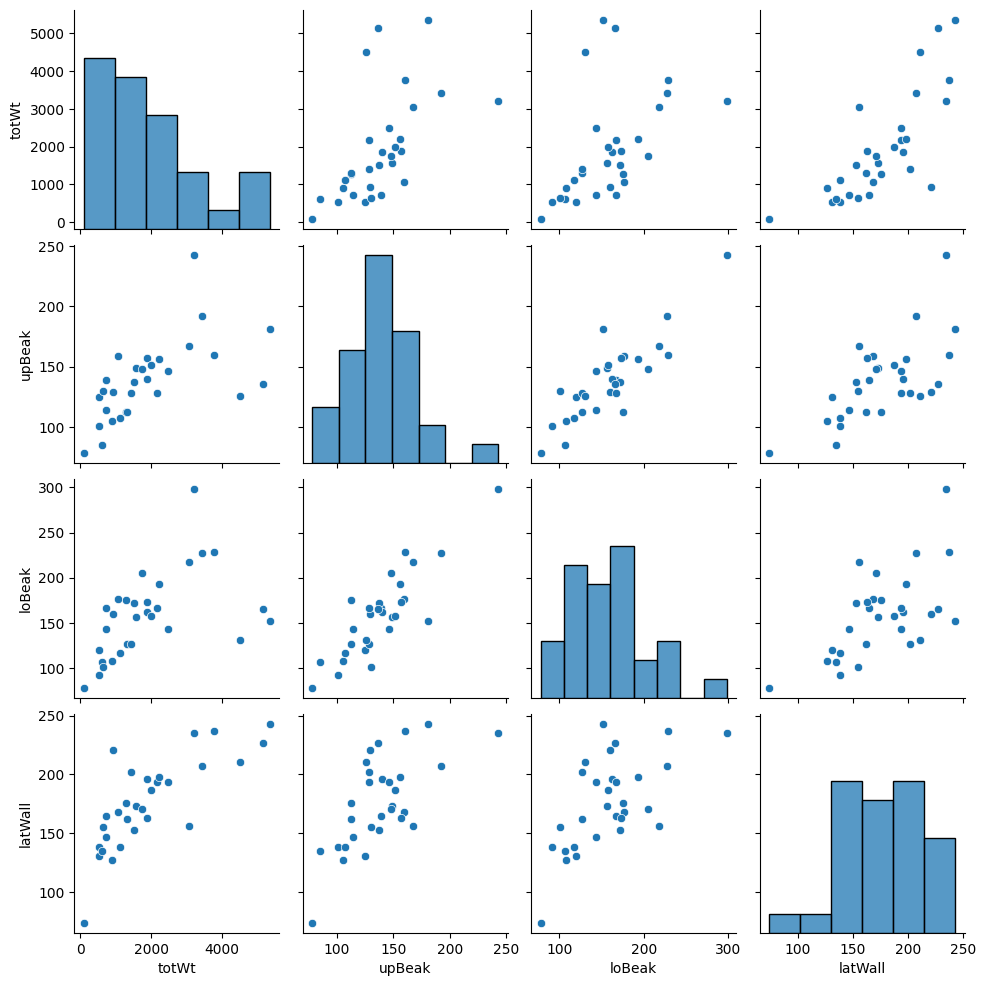

In [ ]:
sns.pairplot(octo)

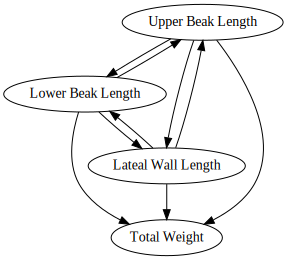

In [ ]:
dag_octo = gv.Digraph(comment='bballh_dag') #bball hierarchy

dag_octo.node('U', 'Upper Beak Length')
dag_octo  .node('L','Lower Beak Length')
dag_octo.node('T','Total Weight')
dag_octo.node('W','Lateal Wall Length')

dag_octo.edges(['UT','LT', 'WT',  'LU', 'UL', 'LW', 'WL', 'WU', 'UW'])

dag_octo

# Models
I wanted to try some GLMs because the pairplot looks pretty strongly linear. I put some polynomial models because I see some curvy trends as well.

In [ ]:
#define the model
model_1 = bmb.Model("`totWt` ~ `upBeak` + `latWall` + `loBeak`", data=octo)
#fit the model, generating posterior predictive samples directly
idata_1 = model_1.fit(idata_kwargs={'log_likelihood': True}, posterior_predictive=True)

In [ ]:
#define the model
model_2 = bmb.Model("totWt ~ latWall + loBeak", data=octo)
#fit the model, generating posterior predictive samples directly
idata_2 = model_2.fit(idata_kwargs={'log_likelihood': True}, posterior_predictive=True)

In [ ]:
#define the model
model_3 = bmb.Model("totWt ~ latWall", data=octo)
#fit the model, generating posterior predictive samples directly
idata_3 = model_3.fit(idata_kwargs={'log_likelihood': True}, posterior_predictive=True)

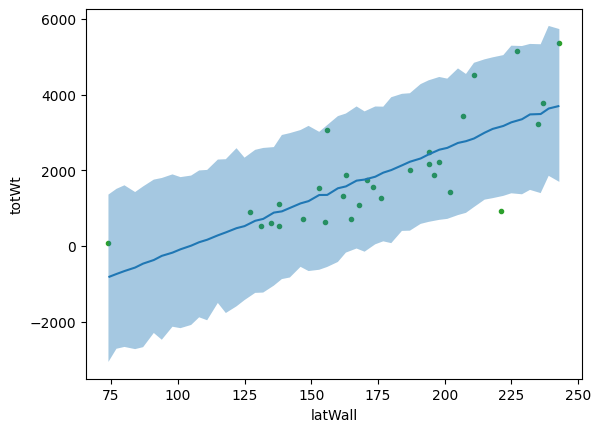

In [43]:
bmb.interpret.plot_predictions(model_3, idata_3, "latWall", pps=True)
plt.plot(octo.latWall, octo.totWt, "C2.", zorder=-3)

In [ ]:
#define the model
model_4 = bmb.Model("totWt ~ latWall + loBeak|upBeak", data=octo)
#fit the model, generating posterior predictive samples directly
idata_4 = model_4.fit(idata_kwargs={'log_likelihood': True}, posterior_predictive=True)

In [ ]:
#degree 3 polynomial model
model_poly_3 = bmb.Model("totWt ~ poly(upBeak + latWall + loBeak, degree=3)", octo)
idata_poly_3 = model_poly_3.fit(idata_kwargs={'log_likelihood': True})

In [ ]:
#degree 3 polynomial model
model_poly_1 = bmb.Model("totWt ~ poly(latWall + loBeak, degree=3)", octo)
idata_poly_1 = model_poly_1.fit(idata_kwargs={'log_likelihood': True})

In [ ]:
#degree 3 polynomial model
model_poly_2 = bmb.Model("totWt ~ poly(latWall, degree=3)", octo)
idata_poly_2 = model_poly_2.fit(idata_kwargs={'log_likelihood': True})

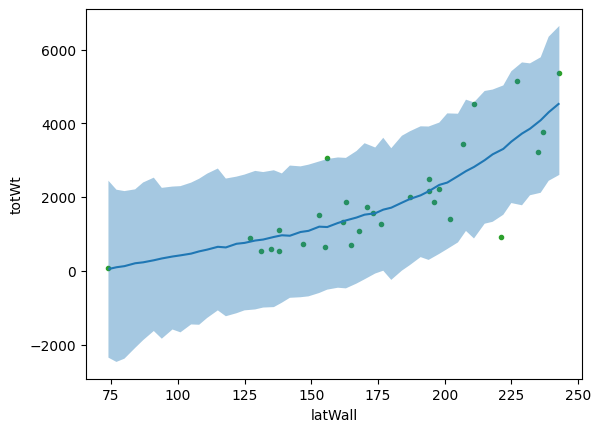

In [34]:
bmb.interpret.plot_predictions(model_poly_2, idata_poly_2, "latWall", pps=True)
plt.plot(octo.latWall, octo.totWt, "C2.", zorder=-3)

I think this model with the polynomial captures the totWt or predicts it better than the other one! I don't know if there's a way to scatterplot my other models that have multiple variables and ran out of time to try it out, but I think either way latWall seems slightly to be the better predictor

In [35]:
cmp_df = az.compare({
    'upBeak + latWall +loBeak': idata_1,
    'latWall + loBeak': idata_2,
    'latWall': idata_3,
    'latWall + loBeak|upBeak': idata_4,
    'poly(upBeak + latWall + loBeak, degree=3)': idata_poly_3,
    'poly(latWall + loBeak, degree=3)': idata_poly_1,
    'poly(latWall, degree=3)': idata_poly_2
})

display(cmp_df)

/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimat

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
"poly(latWall, degree=3)",0,-249.445539,5.144561,0.000000,0.78655,5.436017,0.000000,False,log
latWall + loBeak|upBeak,1,-250.805573,5.035215,1.360034,0.00000,4.876862,2.056813,False,log
latWall,2,-251.063844,5.234277,1.618305,0.00000,4.864641,1.997797,False,log
latWall + loBeak,3,-251.385473,5.594203,1.939934,0.00000,5.072082,1.865705,True,log
upBeak + latWall +loBeak,4,-251.707921,6.030346,2.262382,0.00000,4.718662,2.230592,True,log
"poly(latWall + loBeak, degree=3)",5,-253.683158,4.736926,4.237619,0.00000,5.143859,4.860364,True,log
"poly(upBeak + latWall + loBeak, degree=3)",6,-254.198290,5.351058,4.752751,0.21345,5.480546,5.380800,True,log


<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

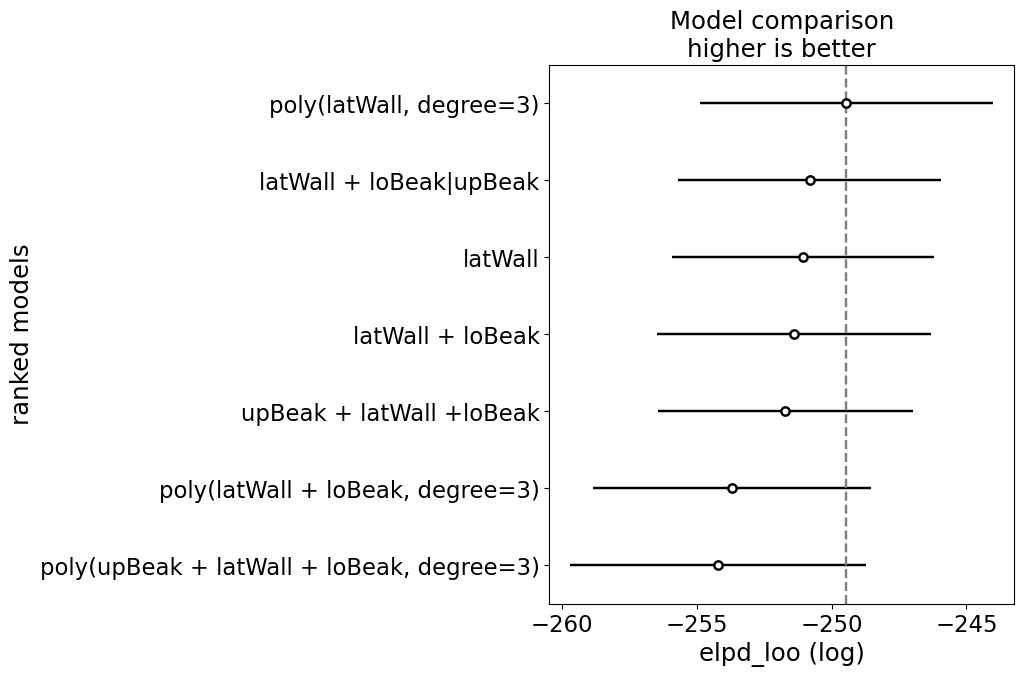

In [45]:
az.plot_compare(cmp_df)

# Conclusion
In conclusion, none of the models are great because the error bars overlap. Maybe I should try playing with interactions more to see if I can get a model that more accurate model? But I think that this shows latWall is a better predictor than loBeak and upBeak is not doing too much. I think the polynomial model is the best based on the elpd_loo but not too much. That makes sense looking at the graphs because although the data has a slight curve, it's not too prominent which accounts for the fact of the error bars overlapping. I feel like after this, my causual diagram would be readjusted showing that mainly latWall best predicts totWt.